<a href="https://colab.research.google.com/github/5atish/TrainingCourse/blob/main/Hugging%20Face%20Agents%20Course%20/Unit%202.%20Frameworks%20for%20AI%20Agents/Unit%202.1%20The%20smolagents%20framework/Tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install smolagents

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 4.8 MB/s eta 0:00:00


In [6]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [7]:
print(bool(os.environ.get("HF_TOKEN")))  # Should print True
print(os.environ.get("HF_TOKEN")[:5])    # Should print "hf_..." prefix, don't print the whole thing

True
hf_cY


In [9]:
from smolagents import CodeAgent, InferenceClientModel, tool
import os

@tool
def catering_service_tool(query: str) -> str:
    """
    This tool returns the highest-rated catering service in Gotham City.
    Args:
        query: A search term for finding catering services.
    """
    services = {
        "Gotham Catering Co.": 4.9,
        "Wayne Manor Catering": 4.8,
        "Gotham City Events": 4.7,
    }
    best_service = max(services, key=services.get)
    return best_service

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",  # keep this — hf-inference doesn't serve this model, as you found already
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(tools=[catering_service_tool], model=model)
result = agent.run(
    "Can you give me the name of the highest-rated catering service in Gotham City?"
)
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in Gotham City?                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = catering_service_tool(query="Gotham City catering service")                     
  print(highest_rated_catering_service)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Out: None

[Step 1: Duration 2.14 seconds| Input tokens: 2,081 | Output tokens: 88]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = "Gotham Catering Co."                                                           
  final_answer(highest_rated_catering_service)                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Catering Co.

[Step 2: Duration 2.56 seconds| Input tokens: 4,347 | Output tokens: 194]

Gotham Catering Co.


In [10]:
from smolagents import CodeAgent, InferenceClientModel, tool
import os

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",  # let HF route to whichever provider actually hosts this model
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(tools=[catering_service_tool], model=model)
result = agent.run("Can you give me the name of the highest-rated catering service in Gotham City?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in Gotham City?                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = catering_service_tool(query="highest-rated catering service in Gotham City")    
  print(highest_rated_catering_service)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Out: None

[Step 1: Duration 1.73 seconds| Input tokens: 2,081 | Output tokens: 61]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = catering_service_tool(query="highest-rated catering service in Gotham City")    
  print(highest_rated_catering_service)                                                                            
  final_answer(highest_rated_catering_service)                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Final answer: Gotham Catering Co.

[Step 2: Duration 1.99 seconds| Input tokens: 4,321 | Output tokens: 146]

Gotham Catering Co.


In [11]:
from smolagents import Tool, CodeAgent, InferenceClientModel
import os

class SuperheroPartyThemeTool(Tool):
    name = "superhero_party_theme_generator"
    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    It returns a unique party theme idea."""
    inputs = {
        "category": {
            "type": "string",
            "description": "The type of superhero party (e.g., 'classic heroes', 'villain masquerade', 'futuristic Gotham').",
        }
    }
    output_type = "string"

    def forward(self, category: str):
        themes = {
            "classic heroes": "Justice League Gala: Guests come dressed as their favorite DC heroes with themed cocktails like 'The Kryptonite Punch'.",
            "villain masquerade": "Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.",
            "futuristic Gotham": "Neo-Gotham Night: A cyberpunk-style party inspired by Batman Beyond, with neon decorations and futuristic gadgets."
        }
        return themes.get(category.lower(), "Themed party idea not found. Try 'classic heroes', 'villain masquerade', or 'futuristic Gotham'.")

# Instantiate the tool
party_theme_tool = SuperheroPartyThemeTool()

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(tools=[party_theme_tool], model=model)

result = agent.run(
    "What would be a good superhero party idea for a 'villain masquerade' theme?"
)
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What would be a good superhero party idea for a 'villain masquerade' theme?                                     │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  villain_masquerade_theme = superhero_party_theme_generator(category="villain masquerade")                        
  print(villain_masquerade_theme)                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.

Out: None

[Step 1: Duration 1.83 seconds| Input tokens: 2,116 | Output tokens: 68]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  villain_masquerade_theme = superhero_party_theme_generator(category="villain masquerade")                        
  final_answer(villain_masquerade_theme)                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.

[Step 2: Duration 1.95 seconds| Input tokens: 4,411 | Output tokens: 138]

Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.


In [14]:
from smolagents import load_tool, CodeAgent, InferenceClientModel

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=InferenceClientModel()
)

agent.run("Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in generating model output:
(Request ID: Root=1-6a932259-62d92d85350737b9248fef9c;d4ab478a-7da5-485b-8d3e-dd5fa0c68f59)

Bad request:
{'message': "The requested model 'Qwen/Qwen3-Next-80B-A3B-Thinking' is not supported by any provider you have 
enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}

[Step 1: Duration 0.10 seconds]

AgentGenerationError: Error in generating model output:
(Request ID: Root=1-6a932259-62d92d85350737b9248fef9c;d4ab478a-7da5-485b-8d3e-dd5fa0c68f59)

Bad request:
{'message': "The requested model 'Qwen/Qwen3-Next-80B-A3B-Thinking' is not supported by any provider you have enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A high-res, photorealistic image of a luxurious superhero-themed party at Wayne Manor. The party is    
  vibrant and filled with made-up superheroes in elaborate costumes, engaging in conversations and activities.     
  Wayne Manor’s architecture and decor are visible in the background, adding to the scene's grandeur and           
  elegance."                                                                                                       
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x7D8B06215310>

[Step 1: Duration 7.19 seconds| Input tokens: 2,111 | Output tokens: 115]

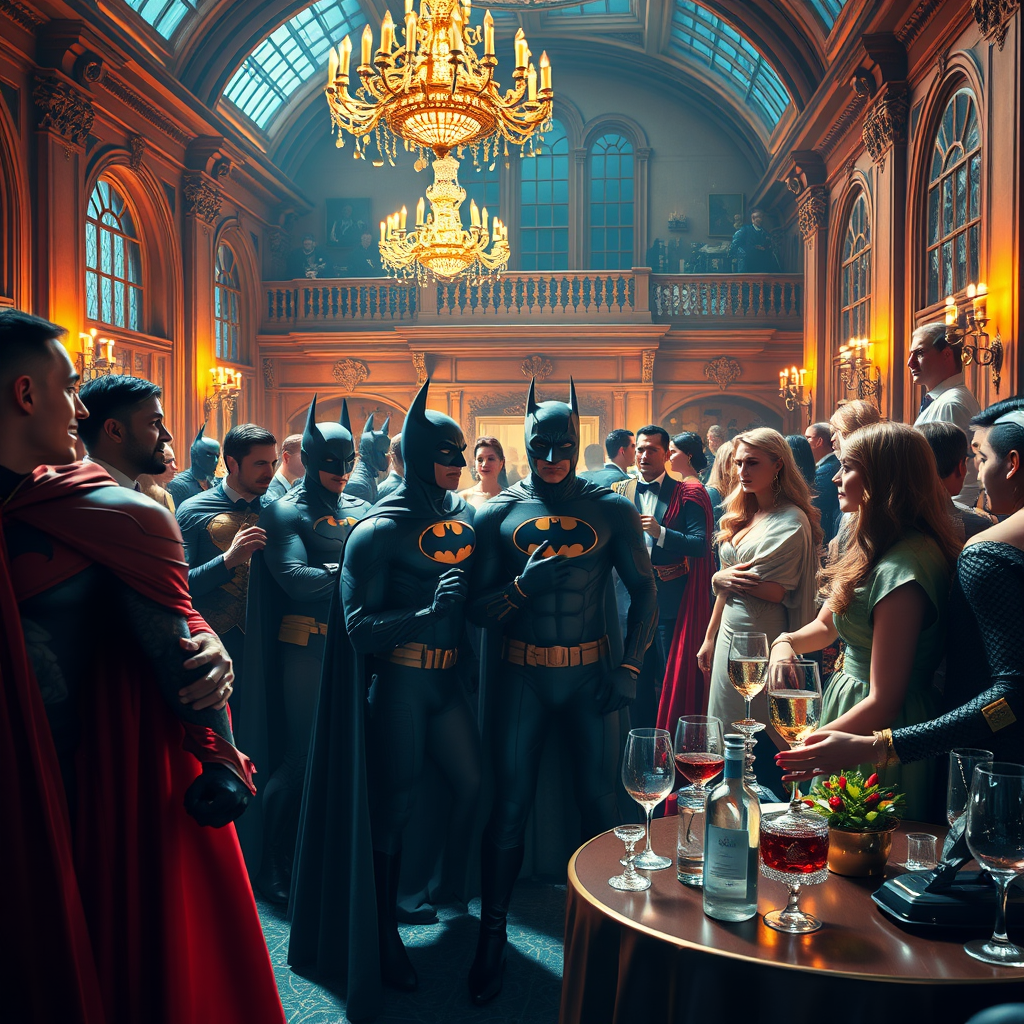

In [15]:
from smolagents import load_tool, CodeAgent, InferenceClientModel
import os

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

agent.run("Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.")

In [17]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

from gradio_client import Client
from smolagents import Tool, CodeAgent, InferenceClientModel

class FluxImageTool(Tool):
    name = "image_generator"
    description = "Generate an image from a prompt"
    inputs = {"prompt": {"type": "string", "description": "The image prompt"}}
    output_type = "string"

    def __init__(self):
        super().__init__()
        self.client = Client("black-forest-labs/FLUX.1-schnell", token=os.environ["HF_TOKEN"])

    def forward(self, prompt: str):
        result = self.client.predict(prompt, api_name="/predict")
        return result

image_generation_tool = FluxImageTool()

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(tools=[image_generation_tool], model=model)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}
)

Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Improve this prompt, then generate an image of it.                                                              │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}.      │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Improve the prompt                                                                                             
  improved_prompt = f"A grand superhero-themed party at Wayne Manor, featuring iconic heroes and heroines. Alfred  
  is overseeing a luxurious gala with impeccable decor and distinguished guests in attendance."                    
  print(improved_prompt)                                                                                           
  # Generate an image using the improved prompt                                                                    
  image = image_generator(prompt=improved_prompt)                                                                  
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
A grand superhero-themed party at Wayne Manor, featuring iconic heroes and heroines. Alfred is overseeing a 
luxurious gala with impeccable decor and distinguished guests in attendance.

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Further improve the prompt                                                                                     
  further_improved_prompt = f"A grand superhero-themed party at Wayne Manor, featuring Batman, Wonder Woman,       
  Superman, and other iconic heroes. Alfred Pennyworth is overseeing a luxurious gala with elegant chandeliers,    
  red carpet, and distinguished guests in stylish attire."                                                         
  print(further_improved_prompt)                                                                                   
  final_answer(further_improved_prompt)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
A grand superhero-themed party at Wayne Manor, featuring Batman, Wonder Woman, Superman, and other iconic heroes. 
Alfred Pennyworth is overseeing a luxurious gala with elegant chandeliers, red carpet, and distinguished guests in 
stylish attire.

Final answer: A grand superhero-themed party at Wayne Manor, featuring Batman, Wonder Woman, Superman, and other 
iconic heroes. Alfred Pennyworth is overseeing a luxurious gala with elegant chandeliers, red carpet, and 
distinguished guests in stylish attire.

[Step 2: Duration 3.19 seconds| Input tokens: 4,542 | Output tokens: 244]

'A grand superhero-themed party at Wayne Manor, featuring Batman, Wonder Woman, Superman, and other iconic heroes. Alfred Pennyworth is overseeing a luxurious gala with elegant chandeliers, red carpet, and distinguished guests in stylish attire.'

In [2]:
pip install -U langchain-community

In [6]:
import os

os.environ['SERPAPI_API_KEY'] = 'f15db0146737c8d30d1d76149909936107c024f0679dc2cea1290059a2d2e473'

In [8]:
!pip install -q mypy_extensions

In [10]:
!pip install -q google-search-results

  Preparing metadata (setup.py) ... done


In [11]:
import serpapi
print(serpapi.__file__)

/usr/local/lib/python3.13/dist-packages/serpapi/__init__.py


In [12]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.environ["SERPAPI_API_KEY"] = "your_serpapi_key_here"

from langchain_community.agent_toolkits.load_tools import load_tools
from smolagents import CodeAgent, InferenceClientModel, Tool

search_tool = Tool.from_langchain(load_tools(["serpapi"])[0])

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    provider="auto",
    token=os.environ["HF_TOKEN"]
)

agent = CodeAgent(tools=[search_tool], model=model)

agent.run("Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive experiences.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive   │
│ experiences.                                                                                                    │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  luxury_entertainment_ideas = search(query="luxury entertainment ideas for superhero-themed event")               
  print(luxury_entertainment_ideas)                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'luxury_entertainment_ideas = search(query="luxury entertainment ideas for 
superhero-themed event")' due to: ValueError: Got error from SerpAPI: Invalid API key. Your API key should be here:
https://serpapi.com/manage-api-key

[Step 1: Duration 24.17 seconds| Input tokens: 2,088 | Output tokens: 65]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Compile final list of luxury entertainment ideas                                                               
  luxury_entertainment_ideas = {                                                                                   
      "Live Performances": live_performances,                                                                      
      "Interactive Experiences": interactive_experiences                                                           
  }                                                                                                                
                                                                                                                   
  # Convert dictionary to string for final answer                                                                  
  luxury_entertainment_str = "\n".join([f"{key}: {', '.join(values)}" for key, values in                           
  luxury_entertainment_ideas.items()])                                                                             
  final_answer(luxury_entertainment_str)                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Live Performances: Live-action superhero theater shows, Superhero-themed musical performances, 
Costumed superhero performances, Magic shows featuring superhero themes
Interactive Experiences: Superhero training camps, Interactive combat demonstrations, Augmented reality experiences
with superheroes, Virtual reality superhero missions

[Step 4: Duration 3.69 seconds| Input tokens: 10,156 | Output tokens: 486]

'Live Performances: Live-action superhero theater shows, Superhero-themed musical performances, Costumed superhero performances, Magic shows featuring superhero themes\nInteractive Experiences: Superhero training camps, Interactive combat demonstrations, Augmented reality experiences with superheroes, Virtual reality superhero missions'

In [30]:
!pip install -q "mcp<2.0" --force-reinstall --no-deps

In [2]:
!pip show mcp | grep Version

Version: 1.29.1


In [3]:
import os
from smolagents import ToolCollection, CodeAgent
from mcp import StdioServerParameters
from smolagents import InferenceClientModel


model = InferenceClientModel("Qwen/Qwen2.5-Coder-32B-Instruct")

In [4]:
server_parameters = StdioServerParameters(
    command="uvx",
    args=["--quiet", "pubmedmcp@0.1.3"],
    env={"UV_PYTHON": "3.12", **os.environ},
)

with ToolCollection.from_mcp(server_parameters, trust_remote_code=True) as tool_collection:
    agent = CodeAgent(tools=[*tool_collection.tools], model=model, add_base_tools=True)
    agent.run("Please find a remedy for hangover.")

/usr/lib/python3.13/contextlib.py:141: FutureWarning: Parameter 'structured_output' was not specified. Currently it defaults to False, but in version 1.25, the default will change to True. To suppress this warning, explicitly set structured_output=True (new behavior) or structured_output=False (legacy behavior). See documentation at https://huggingface.co/docs/smolagents/tutorials/tools#structured-output-and-output-schema-support for more details.
  return next(self.gen)
Exception in thread Thread-3 (_run_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/mcpadapt/core.py", line 244, in _run_loop
    self.loop.run_until_complete(self.task)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^
  File "/usr/

TimeoutError: Couldn't connect to the MCP server after 30 seconds